# 02 — Exploratory Data Analysis

This notebook performs the exploratory analysis of the final processed
dataset from the crossover emotion experiment.

## Objectives

1. Describe the analytical sample.
2. Verify the balance of the crossover design.
3. Characterize missingness and analytical completeness.
4. Explore working-memory accuracy.
5. Explore reaction-time distributions.
6. Examine performance across n-back cognitive-load levels.
7. Examine preliminary patterns across experimental conditions.
8. Inspect participant-level SAM and questionnaire variables.
9. Identify potential anomalies before inferential modeling.

No confirmatory hypothesis testing is performed in this notebook.
Inferential models are reserved for subsequent hypothesis-specific notebooks.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src import config as cfg

from src.utils import (
    initialize_project,
)

from src.visualization import (
    stat_histogram,
    stat_between,
    stat_within,
    stat_scatter,
    stat_corr_matrix,
)

initialize_project()

In [2]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

print(
    f"Dataset shape: {analysis.shape}"
)

print(
    f"Participants: "
    f"{analysis['participant_id'].nunique()}"
)

Dataset shape: (17820, 62)
Participants: 23


In [3]:
dataset_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Participants",
            "Sessions",
            "Missing accuracy",
            "Valid RT",
            "Invalid RT",
        ],
        "value": [
            len(analysis),
            analysis.shape[1],
            analysis[
                "participant_id"
            ].nunique(),
            analysis[
                "session_number"
            ].nunique(),
            analysis[
                "accuracy"
            ].isna().sum(),
            analysis[
                "rt_valid"
            ].sum(),
            (~analysis[
                "rt_valid"
            ]).sum(),
        ],
    }
)

dataset_overview

,metric,value
0,Rows,17820
1,Columns,62
2,Participants,23
3,Sessions,2
4,Missing accuracy,0
5,Valid RT,16754
6,Invalid RT,1066


In [4]:
participant_data = (
    analysis
    .sort_values(
        [
            "participant_id",
            "session_number",
        ]
    )
    .groupby(
        "participant_id",
        as_index=False,
    )
    .first()
)

participant_data.shape

(23, 62)

In [5]:
assert (
    participant_data[
        "participant_id"
    ].nunique()
    ==
    len(participant_data)
)

print(
    "Participant-level dataset: OK"
)

Participant-level dataset: OK


In [6]:
sample_flow = pd.DataFrame(
    {
        "stage": [
            "SAM participants",
            "Participants with n-back",
            "Final analytical participants",
            "Complete crossover",
            "Incomplete crossover",
        ],
        "n": [
            24,
            analysis[
                "participant_id"
            ].nunique(),
            analysis[
                "participant_id"
            ].nunique(),
            participant_data[
                "complete_crossover"
            ].sum(),
            (
                ~participant_data[
                    "complete_crossover"
                ]
            ).sum(),
        ],
    }
)

sample_flow

,stage,n
0,SAM participants,24
1,Participants with n-back,23
2,Final analytical participants,23
3,Complete crossover,21
4,Incomplete crossover,2


In [7]:
participant_data[
    "age"
].describe()

count    23.000000
mean     25.434783
std       3.917630
min      19.000000
25%      24.000000
50%      26.000000
75%      28.000000
max      34.000000
Name: age, dtype: float64

In [8]:
sample_characteristics = pd.DataFrame(
    {
        "N": [
            participant_data[
                "participant_id"
            ].nunique()
        ],
        "Age mean": [
            participant_data[
                "age"
            ].mean()
        ],
        "Age SD": [
            participant_data[
                "age"
            ].std()
        ],
        "Age min": [
            participant_data[
                "age"
            ].min()
        ],
        "Age max": [
            participant_data[
                "age"
            ].max()
        ],
    }
)

sample_characteristics.round(2)

,N,Age mean,Age SD,Age min,Age max
0,23,25.43,3.92,19,34


In [9]:
participant_data[
    "sex"
].value_counts(
    dropna=False
)

sex
1    12
2    11
Name: count, dtype: int64

In [10]:
sequence_balance = (
    participant_data
    .groupby(
        [
            "category",
            "sequence",
            "group_sequence",
            "complete_crossover",
        ],
        dropna=False,
    )
    .size()
    .reset_index(
        name="n_participants"
    )
)

sequence_balance

,category,sequence,group_sequence,complete_crossover,n_participants
0,I,A_B,A to B,True,6
1,II,B_A,B to A,True,6
2,III,C_D,C to D,False,1
3,III,C_D,C to D,True,4
4,IV,D_C,D to C,False,1
5,IV,D_C,D to C,True,5


In [11]:
session_summary = (
    analysis
    .groupby(
        "participant_id"
    )[
        "session_number"
    ]
    .nunique()
    .value_counts()
    .sort_index()
)

session_summary

session_number
1     2
2    21
Name: count, dtype: int64

In [12]:
incomplete_participants = (
    participant_data.loc[
        ~participant_data[
            "complete_crossover"
        ],
        [
            "participant_id",
            "category",
            "sequence",
            "group_sequence",
        ],
    ]
)

incomplete_participants

,participant_id,category,sequence,group_sequence
14,1162,IV,D_C,D to C
19,1214,III,C_D,C to D


In [13]:
trials_per_participant = (
    analysis
    .groupby(
        "participant_id"
    )
    .size()
)

trials_per_participant.describe()

count     23.000000
mean     774.782609
std      116.682147
min      405.000000
25%      810.000000
50%      810.000000
75%      810.000000
max      810.000000
dtype: float64

In [14]:
trials_per_participant.sort_values()

participant_id
1162    405
1214    405
1107    810
1101    810
1122    810
1123    810
1126    810
1106    810
1128    810
1135    810
1151    810
1150    810
1156    810
1157    810
1159    810
1108    810
1170    810
1171    810
1207    810
1208    810
1229    810
1239    810
1249    810
dtype: int64

In [15]:
block_counts = (
    analysis[
        "block_name"
    ]
    .value_counts()
    .sort_index()
)

block_counts

block_name
n_back1    5940
n_back2    5940
n_back3    5940
Name: count, dtype: int64

In [16]:
nback_counts = (
    analysis[
        "nback_level"
    ]
    .value_counts()
    .sort_index()
)

nback_counts

nback_level
1    3960
2    5940
3    3960
4    3960
Name: count, dtype: int64

In [17]:
overall_accuracy = (
    analysis[
        "accuracy"
    ].mean()
)

print(
    f"Overall accuracy: "
    f"{overall_accuracy:.3f}"
)

print(
    f"Overall accuracy: "
    f"{overall_accuracy * 100:.1f}%"
)

Overall accuracy: 0.846
Overall accuracy: 84.6%


In [18]:
accuracy_by_load = (
    analysis
    .groupby(
        "nback_level"
    )
    .agg(
        n_trials=(
            "accuracy",
            "size",
        ),
        accuracy=(
            "accuracy",
            "mean",
        ),
        sd=(
            "accuracy",
            "std",
        ),
    )
    .reset_index()
)

accuracy_by_load

,nback_level,n_trials,accuracy,sd
0,1,3960,0.984596,0.123169
1,2,5940,0.895118,0.306427
2,3,3960,0.764394,0.424431
3,4,3960,0.716919,0.450552


# **Accuracy x Carga**

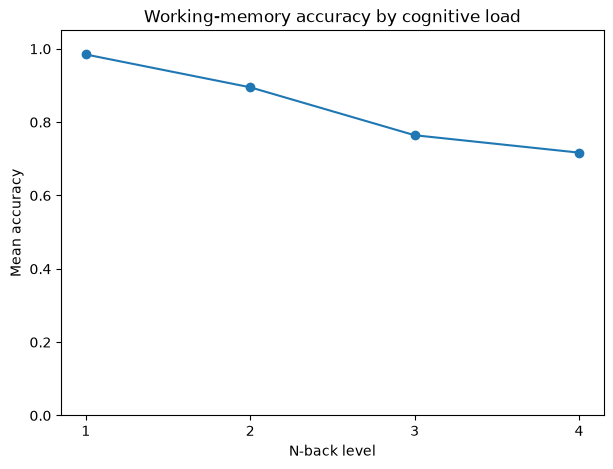

In [19]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    accuracy_by_load[
        "nback_level"
    ],
    accuracy_by_load[
        "accuracy"
    ],
    marker="o",
)

ax.set_xlabel(
    "N-back level"
)

ax.set_ylabel(
    "Mean accuracy"
)

ax.set_xticks(
    [1, 2, 3, 4]
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_title(
    "Working-memory accuracy by cognitive load"
)

plt.show()

In [20]:
accuracy_by_group = (
    analysis
    .groupby(
        "participant_group"
    )
    .agg(
        n_trials=(
            "accuracy",
            "size",
        ),
        accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .reset_index()
)

accuracy_by_group

,participant_group,n_trials,accuracy
0,A,4860,0.869959
1,B,4860,0.859877
2,C,4050,0.829877
3,D,4050,0.818272


In [21]:
accuracy_condition_load = (
    analysis
    .groupby(
        [
            "participant_group",
            "nback_level",
        ]
    )
    ["accuracy"]
    .mean()
    .unstack()
)

accuracy_condition_load

nback_level,1,2,3,4
participant_group,,,,
A,0.994444,0.917284,0.772222,0.772222
B,0.983333,0.906790,0.786111,0.739815
C,0.985556,0.873333,0.757778,0.681111
D,0.973333,0.876296,0.735556,0.658889


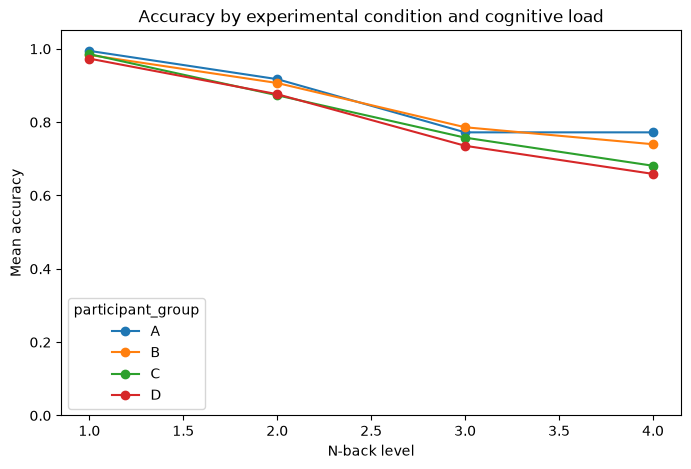

In [22]:
accuracy_condition_load.T.plot(
    marker="o",
    figsize=(8, 5),
)

plt.xlabel(
    "N-back level"
)

plt.ylabel(
    "Mean accuracy"
)

plt.title(
    "Accuracy by experimental condition and cognitive load"
)

plt.ylim(
    0,
    1.05,
)

plt.show()

In [23]:
rt_data = (
    analysis.loc[
        (analysis["accuracy"] == 1)
        &
        (analysis["rt_valid"] == True)
    ]
    .copy()
)

print(
    f"RT analytical trials: "
    f"{len(rt_data)}"
)

print(
    f"Participants: "
    f"{rt_data['participant_id'].nunique()}"
)

RT analytical trials: 14184
Participants: 23


In [24]:
rt_data[
    "reaction_time_ms"
].describe(
    percentiles=[
        .01,
        .05,
        .25,
        .50,
        .75,
        .95,
        .99,
    ]
)

count    14184.000000
mean       827.496545
std        825.720115
min        100.000000
1%         113.000000
5%         163.000000
25%        298.000000
50%        485.500000
75%       1046.000000
95%       2642.850000
99%       4045.340000
max       4971.000000
Name: reaction_time_ms, dtype: float64

c:\Users\NEL\Desktop\NEL\Projects\Papers\experiment-crossover-emotion\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14184.
  res = hypotest_fun_out(*samples, **kwds)


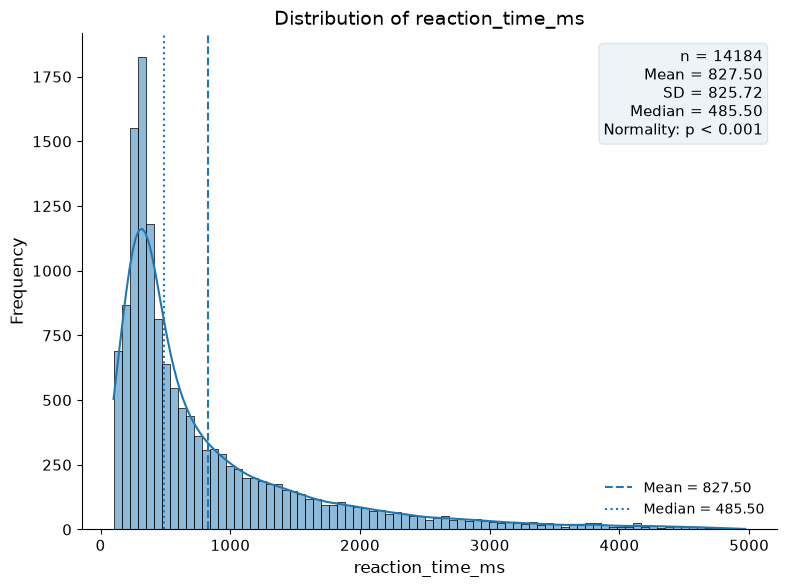

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of reaction_time_ms'}, xlabel='reaction_time_ms', ylabel='Frequency'>,
 {'n': 14184,
  'mean': np.float64(827.4965454032713),
  'median': np.float64(485.5),
  'sd': np.float64(825.7201152045216),
  'normality_p': 6.2444036601747675e-90,
  'test': None})

In [25]:
stat_histogram(
    data=rt_data,
    variable="reaction_time_ms",
)

In [26]:
rt_data[
    "log_reaction_time"
] = np.log(
    rt_data[
        "reaction_time_ms"
    ]
)

In [27]:
rt_data[
    "log_reaction_time"
].describe()

count    14184.000000
mean         6.336495
std          0.848306
min          4.605170
25%          5.697093
50%          6.185179
75%          6.952729
max          8.511376
Name: log_reaction_time, dtype: float64

c:\Users\NEL\Desktop\NEL\Projects\Papers\experiment-crossover-emotion\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14184.
  res = hypotest_fun_out(*samples, **kwds)


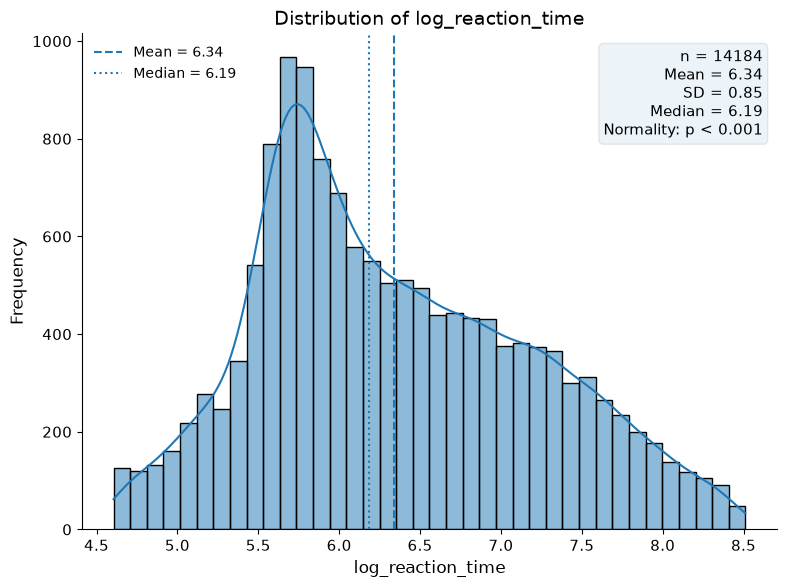

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of log_reaction_time'}, xlabel='log_reaction_time', ylabel='Frequency'>,
 {'n': 14184,
  'mean': np.float64(6.336495040744151),
  'median': np.float64(6.1851787574189885),
  'sd': np.float64(0.8483063489658026),
  'normality_p': 4.9986418430516294e-45,
  'test': None})

In [28]:
stat_histogram(
    data=rt_data,
    variable="log_reaction_time",
)

In [29]:
rt_by_load = (
    rt_data
    .groupby(
        "nback_level"
    )
    .agg(
        n=(
            "reaction_time_ms",
            "size",
        ),
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        sd_rt=(
            "reaction_time_ms",
            "std",
        ),
    )
    .reset_index()
)

rt_by_load

,nback_level,n,mean_rt,median_rt,sd_rt
0,1,3601,556.933352,362.0,520.774072
1,2,5042,887.610472,562.0,833.108716
2,3,2881,960.536966,549.0,938.049010
3,4,2660,935.734962,562.5,929.402450


In [30]:
rt_by_condition = (
    rt_data
    .groupby(
        "participant_group"
    )
    .agg(
        n=(
            "reaction_time_ms",
            "size",
        ),
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        sd_rt=(
            "reaction_time_ms",
            "std",
        ),
    )
    .reset_index()
)

rt_by_condition

,participant_group,n,mean_rt,median_rt,sd_rt
0,A,3945,962.567047,581.0,937.264262
1,B,3967,883.308041,567.0,817.840121
2,C,3135,687.816906,396.0,706.356336
3,D,3137,726.648071,412.0,760.076252


In [31]:
participant_condition = (
    analysis
    .groupby(
        [
            "participant_id",
            "participant_group",
        ]
    )
    .agg(
        accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .reset_index()
)

In [32]:
participant_rt = (
    rt_data
    .groupby(
        [
            "participant_id",
            "participant_group",
        ]
    )
    ["reaction_time_ms"]
    .mean()
    .reset_index(
        name="mean_rt"
    )
)

In [33]:
participant_performance = (
    participant_condition
    .merge(
        participant_rt,
        on=[
            "participant_id",
            "participant_group",
        ],
        how="left",
    )
)

participant_performance.head()

,participant_id,participant_group,accuracy,mean_rt
0,1101,A,0.891358,501.629518
1,1101,B,0.864198,744.668639
2,1106,C,0.854321,427.478689
3,1106,D,0.819753,592.303797
4,1107,C,0.834568,787.457576


In [34]:
participant_performance[
    "ies"
] = (
    participant_performance[
        "mean_rt"
    ]
    /
    participant_performance[
        "accuracy"
    ]
)

In [35]:
participant_performance.groupby(
    "participant_group"
)[
    [
        "accuracy",
        "mean_rt",
        "ies",
    ]
].agg(
    [
        "mean",
        "std",
        "median",
    ]
)

accuracy                         mean_rt              \
                       mean       std    median        mean         std   
participant_group                                                         
A                  0.869959  0.042446  0.869136  951.896259  477.872527   
B                  0.859877  0.040751  0.865432  875.948210  326.968393   
C                  0.829877  0.062480  0.844444  694.711429  342.142512   
D                  0.818272  0.063221  0.820988  730.883733  271.021810   

                                       ies                          
                       median         mean         std      median  
participant_group                                                   
A                  863.740200  1097.811402  552.165297  980.676663  
B                  825.583646  1020.266448  377.082301  953.703117  
C                  613.663537   860.067910  472.446207  804.600733  
D                  621.315134   903.572821  361.861315  759.093412

In [36]:
sam_columns = [
    column
    for column in participant_data.columns
    if column.startswith(
        "sam_"
    )
]

sam_columns

['sam_neg_v1_mean',
 'sam_neg_v2_mean',
 'sam_neg_v3_mean',
 'sam_neg_v3_1_mean',
 'sam_neg_v3_2_mean',
 'sam_neg_v4_mean',
 'sam_neg_v5_mean',
 'sam_neg_v6_mean',
 'sam_neg_v6_3_mean',
 'sam_neg_v6_4_mean',
 'sam_neg_v7_mean',
 'sam_pos_v1_mean',
 'sam_pos_v2_mean',
 'sam_pos_v3_mean',
 'sam_pos_v3_1_mean',
 'sam_pos_v3_2_mean',
 'sam_pos_v4_mean',
 'sam_pos_v5_mean',
 'sam_pos_v6_mean',
 'sam_pos_v6_3_mean',
 'sam_pos_v6_4_mean',
 'sam_pos_v7_mean']

In [37]:
participant_data[
    sam_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
sam_neg_v1_mean,23.0,5.782609,1.881888,1.0,5.0,6.0,7.0,9.0
sam_neg_v2_mean,23.0,4.826087,1.874522,1.0,4.0,5.0,6.5,8.0
sam_neg_v3_mean,23.0,3.478261,1.473079,1.0,2.5,4.0,4.0,7.0
sam_neg_v3_1_mean,23.0,4.130435,1.984127,1.0,3.0,4.0,5.0,9.0
sam_neg_v3_2_mean,23.0,5.130435,2.321918,1.0,3.5,5.0,7.0,9.0
sam_neg_v4_mean,23.0,4.130435,1.816699,1.0,3.0,4.0,4.5,9.0
sam_neg_v5_mean,22.0,5.954545,1.587969,3.0,5.0,6.0,7.0,9.0
sam_neg_v6_mean,23.0,3.130435,1.516705,1.0,2.0,3.0,4.0,6.0
sam_neg_v6_3_mean,23.0,4.434783,1.700965,2.0,3.0,4.0,5.0,8.0
sam_neg_v6_4_mean,23.0,4.826087,2.208500,1.0,3.5,5.0,6.5,9.0


In [38]:
state_trait_columns = [
    "traite_result_neg",
    "traite_result_pos",
    "result_state_neg_pre",
    "result_state_neg_post",
    "result_state_pos_pre",
    "result_state_pos_post",
]

participant_data[
    state_trait_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
traite_result_neg,23.0,13.434783,2.982160,10.0,11.0,13.0,15.5,20.0
traite_result_pos,23.0,13.173913,3.242504,7.0,11.0,13.0,15.0,20.0
result_state_neg_pre,23.0,12.217391,3.088932,6.0,10.5,12.0,14.0,19.0
result_state_neg_post,23.0,14.956522,3.336823,9.0,12.5,15.0,17.0,22.0
result_state_pos_pre,23.0,12.478261,3.462390,6.0,10.5,12.0,15.0,19.0
result_state_pos_post,23.0,12.521739,3.501552,6.0,10.0,12.0,14.0,20.0


In [39]:
participant_data[
    [
        "cog_reap",
        "ex_sup",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
cog_reap,23.0,27.043478,4.497254,19.0,24.0,28.0,29.5,37.0
ex_sup,23.0,16.347826,3.338599,11.0,14.0,17.0,18.5,21.0


In [40]:
participant_missing = (
    participant_data
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

participant_missing[
    participant_missing > 0
]

all_loction_trial_variable    23
sam_neg_v5_mean                1
dtype: int64

In [41]:
correlation_variables = [
    "age",
    "cog_reap",
    "ex_sup",
    "traite_result_neg",
    "traite_result_pos",
    "result_state_neg_pre",
    "result_state_neg_post",
    "result_state_pos_pre",
    "result_state_pos_post",
]

corr_data = (
    participant_data[
        correlation_variables
    ]
    .copy()
)

corr_data.corr()

,age,cog_reap,ex_sup,traite_result_neg,traite_result_pos,result_state_neg_pre,result_state_neg_post,result_state_pos_pre,result_state_pos_post
age,1.000000,-0.292653,-0.182377,-0.020807,0.000933,0.089495,0.199708,0.064398,0.118567
cog_reap,-0.292653,1.000000,0.008029,0.171376,0.121024,-0.200307,-0.284593,0.106612,-0.114079
ex_sup,-0.182377,0.008029,1.000000,0.070863,-0.043632,-0.100226,0.123825,-0.097621,0.127636
traite_result_neg,-0.020807,0.171376,0.070863,1.000000,0.786249,0.369225,0.326304,0.405960,0.556234
traite_result_pos,0.000933,0.121024,-0.043632,0.786249,1.000000,0.354575,0.240194,0.441666,0.532113
result_state_neg_pre,0.089495,-0.200307,-0.100226,0.369225,0.354575,1.000000,0.688914,0.257589,0.547970
result_state_neg_post,0.199708,-0.284593,0.123825,0.326304,0.240194,0.688914,1.000000,0.202531,0.682833
result_state_pos_pre,0.064398,0.106612,-0.097621,0.405960,0.441666,0.257589,0.202531,1.000000,0.574608
result_state_pos_post,0.118567,-0.114079,0.127636,0.556234,0.532113,0.547970,0.682833,0.574608,1.000000


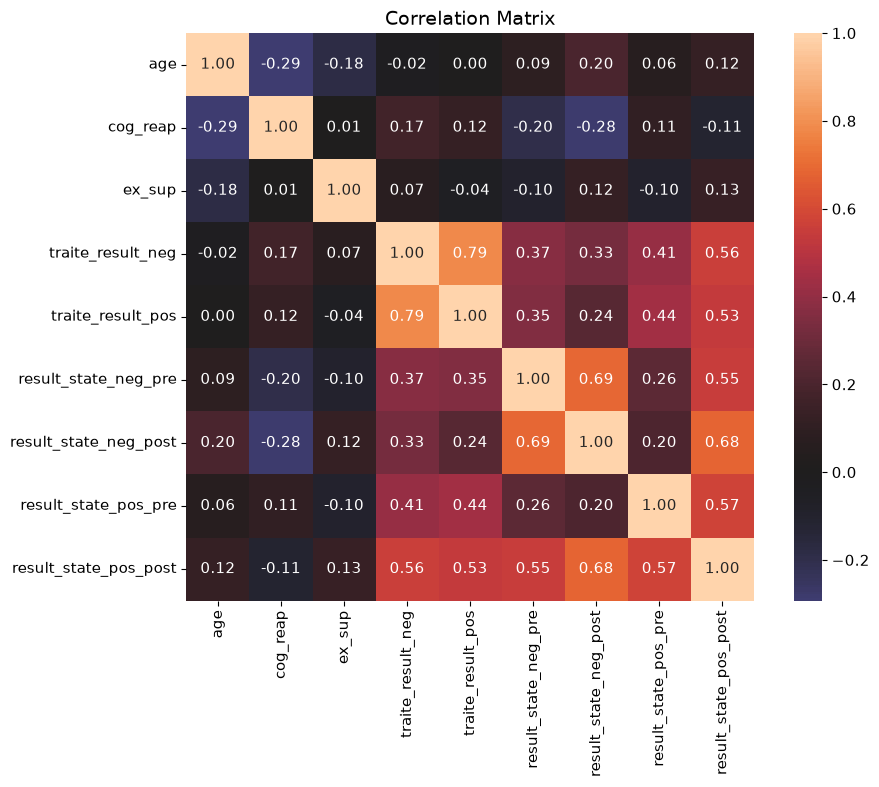

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Correlation Matrix'}>,
                             age  cog_reap    ex_sup  traite_result_neg  \
 age                    1.000000 -0.292653 -0.182377          -0.020807   
 cog_reap              -0.292653  1.000000  0.008029           0.171376   
 ex_sup                -0.182377  0.008029  1.000000           0.070863   
 traite_result_neg     -0.020807  0.171376  0.070863           1.000000   
 traite_result_pos      0.000933  0.121024 -0.043632           0.786249   
 result_state_neg_pre   0.089495 -0.200307 -0.100226           0.369225   
 result_state_neg_post  0.199708 -0.284593  0.123825           0.326304   
 result_state_pos_pre   0.064398  0.106612 -0.097621           0.405960   
 result_state_pos_post  0.118567 -0.114079  0.127636           0.556234   
 
                        traite_result_pos  result_state_neg_pre  \
 age                             0.000933              0.089495   
 cog_reap                   

In [42]:
stat_corr_matrix(
    data=corr_data,
    variables=corr_data.columns.tolist()
)

In [43]:
accuracy_by_load.to_csv(
    cfg.TABLES_DIR_EXPLORATORY
    / "eda_accuracy_by_nback.csv",
    index=False,
)

accuracy_by_group.to_csv(
    cfg.TABLES_DIR_EXPLORATORY
    / "eda_accuracy_by_condition.csv",
    index=False,
)

rt_by_load.to_csv(
    cfg.TABLES_DIR_EXPLORATORY
    / "eda_rt_by_nback.csv",
    index=False,
)

rt_by_condition.to_csv(
    cfg.TABLES_DIR_EXPLORATORY  
    / "eda_rt_by_condition.csv",
    index=False,
)

In [44]:
print(
    "=" * 60
)

print(
    "EXPLORATORY ANALYSIS SUMMARY"
)

print(
    "=" * 60
)

print(
    f"Participants: "
    f"{analysis['participant_id'].nunique()}"
)

print(
    f"Complete crossover: "
    f"{participant_data['complete_crossover'].sum()}"
)

print(
    f"Incomplete crossover: "
    f"{(~participant_data['complete_crossover']).sum()}"
)

print(
    f"Trials: "
    f"{len(analysis)}"
)

print(
    f"Overall accuracy: "
    f"{analysis['accuracy'].mean():.3f}"
)

print(
    f"Valid correct-response RT trials: "
    f"{len(rt_data)}"
)

print(
    f"Median RT: "
    f"{rt_data['reaction_time_ms'].median():.1f} ms"
)

print(
    "=" * 60
)

EXPLORATORY ANALYSIS SUMMARY
Participants: 23
Complete crossover: 21
Incomplete crossover: 2
Trials: 17820
Overall accuracy: 0.846
Valid correct-response RT trials: 14184
Median RT: 485.5 ms


Amostra
  ├── 23 participantes com n-back
  ├── 21 crossover completo
  └── 2 crossover incompleto

N-back
  ├── 17.820 trials
  ├── accuracy global ≈ 84,6%
  └── 14.184 RTs válidos + corretos

Carga cognitiva
  ├── 1-back ≈ 98,5%
  ├── 2-back ≈ 89,5%
  ├── 3-back ≈ 76,4%
  └── 4-back ≈ 71,7%

RT
  ├── distribuição assimétrica
  ├── mediana ≈ 486 ms
  └── média ≈ 827 ms

Próximo passo
  ↓
Manipulation check do SAM
  ↓
Modelos confirmatórios das hipóteses